In [ ]:
import pandas as pd
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import gseapy as gp


In [150]:
def jaccard(A, B):
    """
    Compute Jaccard similarity between two iterables.
    """
    A = set(A)
    B = set(B)

    if not A and not B:
        return 0.0

    return len(A & B) / len(A | B)

In [151]:
def load(d):
    with open(f"../output/{d}/leiden_results/result_communities.pkl", "rb") as f:
        communities = pickle.load(f)
    with open(f"../output/{d}/leiden_results/result_communities_HGNC.pkl", "rb") as f:
        communities_HGNC = pickle.load(f)
    # with open(f"../output/{d}/leiden_results/result_graph.pkl", "rb") as f:
    #     graph = pickle.load(f)    
    with open(f"../output/{d}/gene_to_index_distinct.json", "r") as file:
        gene_to_index_distinct = json.load(file)
        
    return communities,communities_HGNC,gene_to_index_distinct

In [127]:
disease = "bipolar disorder"  # Example disease name
DISEASE = "BIPOLAR"

In [147]:
with open("../../Data/disease_to_snomed_id.json", "r") as file:
    disease_to_snomed_id = json.load(file)
LIST_OF_OTHER_DISEASES = list(disease_to_snomed_id.keys())
LIST_OF_OTHER_DISEASES.remove(DISEASE)
LIST_OF_OTHER_DISEASES.append("NONE")

In [128]:
with open(f"../output/{DISEASE}/leiden_results/result_communities_HGNC.pkl", "rb") as f:
    communities_HGNC = pickle.load(f)
with open(f"../output/{DISEASE}/leiden_results/result_communities_HGNC_selected.pkl", "rb") as f:
    communities_HGNC_selected = pickle.load(f)

In [129]:
open_targets = pd.read_csv("../../Data/openTargets.tsv", sep="\t")
print(len(open_targets))

2842003


In [130]:
open_targets

,diseaseId,targetId,score,evidenceCount,diseaseCommonName,geneCommonName
0,DOID_0050890,ENSG00000001084,0.031799,4,synucleinopathy,GCLC
1,DOID_0050890,ENSG00000004142,0.002217,1,synucleinopathy,POLDIP2
2,DOID_0050890,ENSG00000004478,0.002217,1,synucleinopathy,FKBP4
3,DOID_0050890,ENSG00000004948,0.002957,1,synucleinopathy,CALCR
4,DOID_0050890,ENSG00000005381,0.002217,1,synucleinopathy,MPO
...,...,...,...,...,...,...
2841998,Orphanet_99946,ENSG00000172409,0.039183,1,Charcot-Marie-Tooth disease type 2A1,CLP1
2841999,Orphanet_99946,ENSG00000179902,0.063280,4,Charcot-Marie-Tooth disease type 2A1,CFAP276
2842000,Orphanet_99946,ENSG00000196876,0.041851,1,Charcot-Marie-Tooth disease type 2A1,SCN8A
2842001,Orphanet_99947,ENSG00000101986,0.033780,1,Charcot-Marie-Tooth disease type 2A2,ABCD1


In [131]:
disease_related_genes_df = open_targets[open_targets["diseaseCommonName"] == disease]
disease_related_genes_df = disease_related_genes_df.sort_values(by="score", ascending=False)
print("Number of related genes:",len(disease_related_genes_df))

Number of related genes: 2864


In [132]:
disease_related_genes_df

,diseaseId,targetId,score,evidenceCount,diseaseCommonName,geneCommonName
1632258,MONDO_0004985,ENSG00000136531,0.727275,152,bipolar disorder,SCN2A
1632544,MONDO_0004985,ENSG00000149295,0.685297,674,bipolar disorder,DRD2
1631311,MONDO_0004985,ENSG00000082701,0.625937,253,bipolar disorder,GSK3B
1631513,MONDO_0004985,ENSG00000102468,0.613610,620,bipolar disorder,HTR2A
1632498,MONDO_0004985,ENSG00000147246,0.611434,489,bipolar disorder,HTR2C
...,...,...,...,...,...,...
1633722,MONDO_0004985,ENSG00000232125,0.001290,1,bipolar disorder,DYTN
1631719,MONDO_0004985,ENSG00000111445,0.001273,1,bipolar disorder,RFC5
1632588,MONDO_0004985,ENSG00000151360,0.001250,1,bipolar disorder,ALLC
1632053,MONDO_0004985,ENSG00000128016,0.001225,1,bipolar disorder,ZFP36


In [133]:
for i in range(len(communities_HGNC_selected)):
    print(i)
    print(disease_related_genes_df[(disease_related_genes_df["geneCommonName"].isin(communities_HGNC_selected[i])) & 
                                   (disease_related_genes_df["score"] > 0.2)]
          [["geneCommonName","evidenceCount","score"]])
    print("=" * 50)

0
        geneCommonName  evidenceCount     score
1632043         BCL11B              4  0.467104
1632777           NFIA              5  0.462852
1633486        SPATS2L              2  0.407621
1632779          FUBP1              2  0.361244
1633081           RBKS              3  0.354600
1632471          SSBP2              1  0.314633
1632608         SETBP1              1  0.310320
1633149          FKBP2              1  0.293819
1632605          TLCD4              2  0.282015
1632999         LRATD2              1  0.269189
1632479          TENM2              3  0.260607
1631328          DDHD2              4  0.259781
1631800           GPD2              1  0.258706
1632387         ZCCHC2              1  0.258000
1632296          IFI44              2  0.249333
1631828          PLCL1              2  0.240978
1631378        LRRFIP2              1  0.237998
1632913          IKBIP              4  0.228246
1632022        DYNLRB1              1  0.208856
1632980         NT5DC2             10 

In [134]:
top_comm_len = 30
top_score_len = 20

In [135]:
opentarget_comm_score_matrix = np.zeros([top_comm_len,top_score_len])
for i in range(top_comm_len):
    score_list = list(disease_related_genes_df[disease_related_genes_df["geneCommonName"].isin(communities_HGNC[i])]["score"])[:20]
    score_list_padded = score_list + [0] * max(0, top_score_len - len(score_list))
    opentarget_comm_score_matrix[i] = score_list_padded

In [136]:
def plot_heatmap(M, row_labels=None, col_labels=None,
                 cmap="viridis", vmin=None, vmax=None, save_path = None):
    """
    Plot a heatmap for a 2D matrix, with optional row/column labels.
    """
    M = np.asarray(M)

    plt.figure()
    im = plt.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    plt.colorbar(im)

    # Optional labels
    if row_labels is not None:
        plt.yticks(range(len(row_labels)), row_labels)
    else:
        plt.yticks([])

    if col_labels is not None:
        plt.xticks(range(len(col_labels)), col_labels, rotation=90)
    else:
        plt.xticks([])

    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()

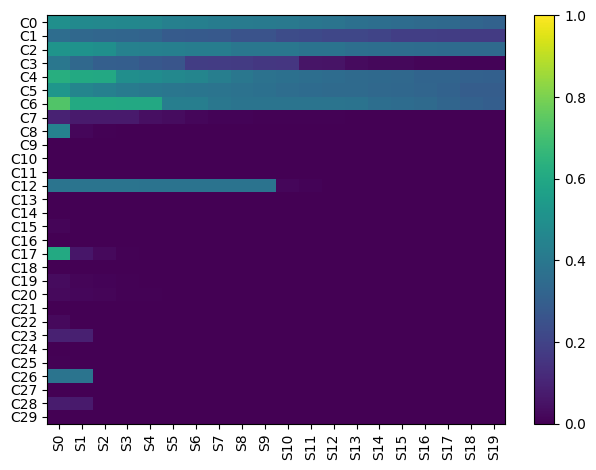

In [137]:
plot_heatmap(
    opentarget_comm_score_matrix, 
    row_labels=[f"C{i}" for i in range(opentarget_comm_score_matrix.shape[0])],
    col_labels=[f"S{j}" for j in range(opentarget_comm_score_matrix.shape[1])],
    vmin=0, vmax=1
)

# Community deepdive

In [165]:
comm_idx = 12

In [166]:
for c in communities_HGNC:
    print(len(c))

4089
3522
3299
3160
2633
2477
1162
772
435
43
20
15
15
11
11
8
7
6
5
5
5
4
4
3
3
2
2
2
2
2
1
2
2
2
2
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


In [167]:
comm_HGNC = communities_HGNC[comm_idx]

In [168]:
len(comm_HGNC)

15

In [169]:
enr_go = gp.enrichr(
    gene_list=comm_HGNC,
    gene_sets=['GO_Biological_Process_2023',
            'GO_Molecular_Function_2023',
            'GO_Cellular_Component_2023',
            'KEGG_2021_Human',
            'Reactome_2022'],
    organism='Human',
    outdir=None # don't write to disk
)
go_df = enr_go.results

In [170]:
go_df_filtered = go_df[go_df["Adjusted P-value"] < 0.001]

In [171]:
go_df_filtered = go_df_filtered.sort_values(["Adjusted P-value"])

In [172]:
go_df_filtered

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
51,GO_Cellular_Component_2023,GABA-A Receptor Complex (GO:1902711),13/18,6.834082e-41,1.025112e-39,0,0,25974.000000,2.402181e+06,GABRQ;GABRP;GABRA6;GABRA5;GABRA4;GABRA3;GABRG3...
34,GO_Molecular_Function_2023,GABA-A Receptor Activity (GO:0004890),13/18,6.834082e-41,1.161794e-39,0,0,25974.000000,2.402181e+06,GABRQ;GABRP;GABRA6;GABRA5;GABRA4;GABRA3;GABRG3...
35,GO_Molecular_Function_2023,GABA Receptor Activity (GO:0016917),13/21,1.623088e-39,1.379624e-38,0,0,16231.312500,1.449724e+06,GABRQ;GABRP;GABRA6;GABRA5;GABRA4;GABRA3;GABRG3...
66,KEGG_2021_Human,Nicotine addiction,13/40,9.589475e-35,1.054842e-33,0,0,4804.703704,3.763515e+05,GABRQ;GABRP;GABRA6;GABRA5;GABRA4;GABRA3;GABRG3...
68,KEGG_2021_Human,Morphine addiction,13/91,1.521930e-29,5.580411e-29,0,0,1658.916667,1.100774e+05,GABRQ;GABRP;GABRA6;GABRA5;GABRA4;GABRA3;GABRG3...
67,KEGG_2021_Human,GABAergic synapse,13/89,1.116268e-29,5.580411e-29,0,0,1702.743421,1.135133e+05,GABRQ;GABRP;GABRA6;GABRA5;GABRA4;GABRA3;GABRG3...
69,KEGG_2021_Human,Retrograde endocannabinoid signaling,13/148,1.205252e-26,3.314444e-26,0,0,955.740741,5.703911e+04,GABRQ;GABRP;GABRA6;GABRA5;GABRA4;GABRA3;GABRG3...
70,KEGG_2021_Human,Neuroactive ligand-receptor interaction,14/341,1.983589e-24,4.363897e-24,0,0,841.626911,4.593358e+04,GABRQ;GABRP;GABRA6;GABRA5;GABRA4;GABRA3;GABRG3...
0,GO_Biological_Process_2023,Gamma-Aminobutyric Acid Signaling Pathway (GO:...,9/20,5.942231e-25,2.020358e-23,0,0,2723.727273,1.519364e+05,GABRR3;GABRR1;GABRA6;GABRA5;GABRA4;GABRA3;GABR...
1,GO_Biological_Process_2023,Chemical Synaptic Transmission (GO:0007268),13/273,4.390162e-23,7.463275e-22,0,0,493.125000,2.538612e+04,GABRQ;GABRP;GABRA6;GABRA5;GABRA4;GABRA3;GABRG3...


In [173]:
list(go_df_filtered["Term"])

['GABA-A Receptor Complex (GO:1902711)',
 'GABA-A Receptor Activity (GO:0004890)',
 'GABA Receptor Activity (GO:0016917)',
 'Nicotine addiction',
 'Morphine addiction',
 'GABAergic synapse',
 'Retrograde endocannabinoid signaling',
 'Neuroactive ligand-receptor interaction',
 'Gamma-Aminobutyric Acid Signaling Pathway (GO:0007214)',
 'Chemical Synaptic Transmission (GO:0007268)',
 'Benzodiazepine Receptor Activity (GO:0008503)',
 'Extracellular Ligand-Gated Monoatomic Ion Channel Activity (GO:0005230)',
 'GABA-gated Chloride Ion Channel Activity (GO:0022851)',
 'Inhibitory Extracellular Ligand-Gated Monoatomic Ion Channel Activity (GO:0005237)',
 'GABA Receptor Activation R-HSA-977443',
 'Synaptic Transmission, GABAergic (GO:0051932)',
 'Ligand-Gated Monoatomic Anion Channel Activity (GO:0099095)',
 'Neuron Projection (GO:0043005)',
 'Dendrite Membrane (GO:0032590)',
 'Transmitter-Gated Monoatomic Ion Channel Activity (GO:0022824)',
 'Regulation Of Postsynaptic Membrane Potential (GO:0

# Comparison

In [162]:
LIST_OF_OTHER_DISEASES

['SCHIZOPHRENIA', 'LEUKEMIA', 'PARKINSON', 'DIABETES', 'BREASTCANCER', 'NONE']

In [163]:
for d2 in LIST_OF_OTHER_DISEASES:
    print(d2)
    communities2,communities_HGNC2,gene_to_index_distinct2 = load(d2) 
    jslist = []
    for c in communities_HGNC2:
        jslist.append(jaccard(comm_HGNC,c))
    print(max(jslist))   

SCHIZOPHRENIA
0.00122737035900583
LEUKEMIA
0.0012795905310300703
PARKINSON
0.0012062726176115801
DIABETES
0.0012051822838204278
BREASTCANCER
0.0012319063751154912
NONE
0.0019011406844106464
